#Uczenie ze wzmocnieniem

Celem tego laboratorium jest zaznajomienie się z koncepcją uczenia ze wzmocnieniem na przykładzie algorytmów Q-Learning.

Poniższy wzór prezentuje podstawowy schemat działania algorytmu Q-Learning.

$$
Q^{new}(s_t,a_t) \gets (1- α) * \underbrace{ Q(s_t,a_t)}_{\text{old value}} +  \underbrace{α}_{\text{learning rate}} *  \overbrace{( \underbrace{r_t}_{reward} +  \underbrace{γ}_{\text{discount factor}} * \underbrace{\max_{a}{Q}(s_{t+1},a))}_{\text{estimated of optimal future value}}}^{\text{learned value}}
$$


## Zastosowania
* inteligentne sterowanie optymalne,
* uczące się roboty,
* gry planszowe,
* optymalizacja kombinatoryczna i szeregowanie.(np. Reakcji chemicznych)

Do najbardziej spektakularnych przykładów należy użycie uczenia się ze wzmocnieniem w połączeniu z reprezentacją funkcji wartości za pomocą sieci neuronowej do gry w trik-traka (backgammon): uzyskany w ten sposób program na podstawie własnej gry (ze sobą) doszedł do mistrzostwa (należy do kilku najlepszych graczy na świecie).
Oraz AlphaGo and AlphaGo Zero, AlphaGo używało sieci wartości (value networks) i przeszukiwało je przy użyciu MCTS monte carlo tree search kiedy  AlphaGo Zero uczenia ze wzmocnieniem. 100 - 0 dla  AlphaGo Zero

## Jak to działa

Zakładamy, że nasz byt uczący się do agent posiadający dwie poniższe zdolności:
* Postrzegania aktualnego stanu środowiska w którym egzystuje. Stan taki oznaczamy zwyczajowo literą **s** (state) z indeksem **t** (time) oznaczającym czas, w którym dany stan miałby być postrzegany. Stanem takim może być np. obraz postrzegany przez kamerę, odczyty z sensorów autonomicznego robota, położenie pionków na planszy do gry…czy nawet treść maila ocenianego przez filtr antyspamowy. Uwaga! Stan postrzegany przez agenta nie musi być pełnym opisem stanu całego środowiska – nie zawsze wiemy co czai się za rogiem.
* Wykonywania akcji, które potencjalnie mają wpływ na stan środowiska i jego miejsce w tymże. Akcje oznaczamy literą **a** (action). Akcją może być wciśnięcie mocniej pedału gazu, przesunięcie figury szachowej, strzał w grze FPS, nawiercenie gruntu…a nawet nie robienie kompletnie niczego (decyzja o bierności również jest decyzją).


Dodatkowo potrzebny jest nam zewnętrzny nadzorca, który potrafi oceniać skutki naszych działań.

*  Za każdym razem gdy w stanie **s** wykonamy akcję **a** nadzorca ocenia skutki takiego działania i przyznaje pewną nagrodę **r** (reward). Nagroda może być ujemna – i zwykle nagrodę taką nazywamy po prostu karą. Nagrody i kary powinny określać pożądane i niepożądane zachowania. Przyznajemy nagrodę za zaparkowanie we właściwym miejscu, fraga, czy zbicie figury bez straty własnej. Przyznajemy karę za stratę bierki, uszkodzenie pojazdu, czy zmarnowane paliwo.


## Q-learning
Q-learning (jak sama nazwa wskazuje) dodaje jeszcze jeden element do układanki: funkcję $Q$ (quality). Dla danej pary „stan i akcja jaką planujemy wykonać” zwraca ona przewidywaną sumę nagród, jakie dostaniemy w przyszłości w konsekwencji wykonania tej akcji. Uwaga! Predykcja ta (szczególnie na początku procesu uczenia) nie musi być trafna i może mocno odbiegać od tego, co wydarzy się w rzeczywistości.
Funkcja Q wyraża właśnie całą zgromadzoną (na bazie wcześniejszych doświadczeń) przez agenta wiedzę.
Jak ją zaimplementować? Na potrzeby tego laboratorium skorzystamy z jednego z najprostszych wariantów – słownika $(s, a) \to r$. W praktyce wykorzystujemy bardziej złożone modele reprezentacji wiedzy – np. wielowarstwową sieć neuronową.


1.    Podejmij decyzję w jaki sposób wybrać następną akcję. Pojawia się pytanie, czy bazować na wcześniejszej wiedzy, czy też wykonać eksperyment. Szansę na ten drugi scenariusz opisuje parametr sterujący $ɛ$ (experiment rate).
   * a  Dla danego stanu $s_t$ rozważ wszystkie możliwe akcje $a$. Wybierz tą, dla której $Q(s_t,a)$ będzie największe. To z punktu widzenia posiadanej wiedzy decyzja racjonalna.
   * b  Ze zbioru dostępnych akcji wybierz losowo akcję $a$. To zaś eksperyment pozwalający na eksplorację nieprzetestowanych jeszcze możliwości.
2. Wykonaj wybraną akcję $a_t$.
3. Zaobserwuj nowy stan środowiska $s_{t+1}$.
4. Otrzymaj nagrodę o wartości $r_t$.
5. Zaktualizuj wartość przypisaną w słowniku do $Q(s_t,a_t)$ w oparciu o wzór podany na początku. Zwróć uwagę na poniższe kwestie.
   * a. Nowa wartość predykcji jest średnią ważoną uprzednio znajdującego się pod tym kluczem wpisu (dotychczasowa wiedza) oraz wniosków z nowego doświadczenia (człon w nawiasie). Stosunek między jednym a drugim (wpływający na to jak „konserwatywny i stabilny w poglądach” jest nasz algorytm) wyraża współczynnik $α$.
   * b. Predykcja składa się z dwóch członów: nagrody już otrzymanej ($r_t$) oraz przewidywanych nagród w kolejnych krokach (definicja jest jak widać rekurencyjna z natury). Ten drugi człon generuje jednak dwa dodatkowe problemy. Po pierwsze jest z definicji mniej wiarygodny (rzeczywista nagroda już „w rękach”, a luźne przewidywania na temat tego jakie nagrody jeszcze nas spotkają). Po drugie zaś (poprzez tą właśnie rekurencyjną zależność) powodowałby on, że wszystkie ścieżki do nagrody są równie dobre, tak długo jak „kiedyś tam” ją dostaniemy. W związku z tym osłabia się wpływ tego składnika wykorzystując współczynnik $γ$.
6. Wykonaj ponownie punkt pierwszy.


Warto zwrócić uwagę, że parametry algorytmu nie muszą być stałe w trakcie całego procesu uczącego. W szczególności $ɛ$ i $α$ powinny startować z dużych wartości (otwartość na nową wiedzę, skłonność do poszukiwań), a następnie spadać (mniej nieodpowiedzialnych eksperymentów, bazowanie na wcześniejszych doświadczeniach).

In [1]:
from collections import defaultdict, deque
import math
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from itertools import product

## Balansowanie kijkiem na wózku
Pierwszy problemem, który rozwiążemy z użyciem Q-Learningu, jest próba utrzymania w pozycji pionowej kijka umieszczonego na poruszającym się wózku (patrz obrazek powyżej). Problem ten
pochodzi z biblioteki Gymnasium gromadzącej zadania testowe dla algorytmów uczących się. W tym celu skorzystamy z umieszczonego w pliku balance.py schematu rozwiązania. Omówmy w zarysie jego zawartość.

### Omówineine kodu
Init

Tworzymy środowisko na bazie przykładu z biblioteki o nazwie „CartPole-v1”
Ustawiamy licznik prób na 1
Definiujemy górne i dolne granice poszczególnych zmiennych opisujących stan. Będą przydatne podczas jego dyskretyzacji.
* Pierwsza z nich to pozycja wagonika w osi lewo-prawo. Ma ona zakres od -4.8 do 4.8, definiowany przez bibliotekę (i z tego zakresu skorzystamy).
* Druga to prędkość wagonika w tej osi. W teorii może być ona dowolna (stąd zakres od -inf do inf deklarowany przez bibliotekę). W praktyce znacznie wygodniej będzie założyć, że mieści się on między -0.5 a 0.5.
* Trzecia to wychylenie kątowe drążka od pozycji równowagi. Tu również skorzystamy z wartości deklarowanych przez bibliotekę.
* Ostatnią jest prędkość kątowa drążka. Ponownie koniecznie było zawężenie rozważanych wartości do rozsądnego zakresu.

Funkcja main tworzy nowy byt uczący i uruchamia go na 10000 podejść do problemu.

Metoda learn zawiera główną pętlę uczącą. Wykonujemy zadaną liczbę podejść, po każdym z nich wypisując otrzymaną sumę nagród.

Metoda attempt definiuje przebieg jednego podejścia.
* Najpierw resetuje stan środowiska i zeruje zmienną sumującą nagrody.
*  Następnie wybiera akcję do podjęcia.
Deklaruje jej wykonanie i poznaje rezultaty.
* Aktualizuje wiedzę.
* Oraz aktualizuje stan zgromadzonych nagród.
  * W tym problemie dostajemy 1 jednostkę nagrody za każdą iterację w trakcie której kijek nie przewrócił się.
* Kroki te powtarza aż spełniony zostanie jeden z warunków stopu (zmienne terminated, truncated).
  * Pręt przechyli się poniżej granicznego wychylenia kilkunastu stopni.
  * Wagonik wyjedzie poza dozwolony obszar.
  * Uda się utrzymać pręt w pionie przez 500 jednostek czasu. Sukces!


Metoda discretise jest pierwszą z tych, które wymagają właściwej implementacji. Aby skorzystać ze słownika jako reprezentacji wiedzy musimy dokonać dyskretyzacji otrzymanych obserwacji stanu poprzez podział na kubełki. W przeciwnym wypadku nie będzie szans na uczenie się (algorytm musi trafić wielokrotnie na dany klucz w słowniku, by ustalić jego finalną wartość). W końcu pozycja -1.353 to coś zupełnie innego niż -1.357. Możemy jednak reprezentować obie jako np. kubełek numer 3 (od -1.5 do -1.0).

* Ta metoda ma zwracać dla każdej zmiennej opisującej zaobserwowany stan numer kubełka do którego przynależy.
* Obecnie zwraca cztery razy 1 – zakłada istnienie tylko jednego kubełka na każdą zmienną i do niego wrzuca wszystkie obserwacje.
* Musimy ją zaimplementować, by zwracała numery kubełków do których zostały przyporządkowane obserwacje – np. 2, 4, 7, 1.
* Uwaga! Im więcej kubełków tym bardziej „rozrzedzona” jest wiedza (i to wykładniczo!) i tym trudniej cokolwiek nauczyć Q-Learning oparty o słownik. Starajmy się zawsze minimalizować ich liczbę. Dla tego problemu polecam wartości między 2 a 8 kubełków na daną zmienną (sam dobierz ich właściwą liczbę – to jeden z parametrów algorytmu!).


Metoda pick_action  ma za zadanie wybrać kolejną akcję do wykonania zgodnie z punktem 1. opisanego wcześniej schematu algorytmu.
* Na razie jednakże zamiast tego zawsze wybiera losową akcję ze zbioru dostępnych.
* Dostępne są dwie akcje: 0 – popchnij wózek w lewo i 1 – popchnij wózek w prawo. Ją też musimy zaimplementować!

Ostanią do realizacji jest metoda update_knowledge.
* Powinna aktualizować naszą wiedzę (słownik) zgodnie z omówionym schematem.
* Zamiast tego…chwilowo nie robi zupełnie nic.



## Zadanie 1 Uzupełnij luki w kodzie oraz dobierz tak parametry by system działał.


Jeżeli zaimplementujemy wszystko prawidłowo, to nagrody zdobywane przez agenta w kolejnych podejściach powinny systematycznie rosnąć. Optymalne rozwiązanie powinno powtarzalnie uzyskiwać nagrodę 500 jednostek (zajrzyj do zadania 2). Jest również możliwość wyrenderowania całej symulacji jednak jest to problematyczne z poziomu colaba ta biblioteka może ci pomóc https://github.com/ryanrudes/renderlab


In [2]:
class QLearner:
    def __init__(
        self,
        env_name='CartPole-v1',
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.001,
        buckets=(1, 1, 6, 12),
        failure_penalty=-10.0,
        seed=None,
    ):
        self.environment = gym.make(env_name)
        self.attempt_no = 1

        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.buckets = buckets
        self.failure_penalty = failure_penalty
        self.seed = seed

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.q_table = defaultdict(lambda: np.zeros(self.environment.action_space.n, dtype=float))

        self.upper_bounds = [
            self.environment.observation_space.high[0],
            0.5,
            self.environment.observation_space.high[2],
            math.radians(50),
        ]
        self.lower_bounds = [
            self.environment.observation_space.low[0],
            -0.5,
            self.environment.observation_space.low[2],
            -math.radians(50),
        ]

    def learn(self, max_attempts):
        rewards = []
        for _ in range(max_attempts):
            reward_sum = self.attempt()
            rewards.append(reward_sum)
        return rewards

    def attempt(self):
        if self.seed is not None and self.attempt_no == 1:
            observation_raw, _ = self.environment.reset(seed=self.seed)
        else:
            observation_raw, _ = self.environment.reset()

        observation = self.discretise(observation_raw)
        terminated, truncated = False, False
        reward_sum = 0.0

        while not truncated and not terminated:
            action = self.pick_action(observation)
            new_observation_raw, reward, terminated, truncated, _ = self.environment.step(action)
            new_observation = self.discretise(new_observation_raw)

            reward_sum += reward

            learning_reward = reward
            if terminated and reward_sum < 499:
                learning_reward = self.failure_penalty

            self.update_knowledge(
                action=action,
                observation=observation,
                new_observation=new_observation,
                reward=learning_reward,
                terminated=terminated,
            )
            observation = new_observation

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.attempt_no += 1
        return reward_sum

    def discretise(self, observation):
        discretised = []
        for i, value in enumerate(observation):
            scaling = (value - self.lower_bounds[i]) / (self.upper_bounds[i] - self.lower_bounds[i])
            bucket_index = int(round((self.buckets[i] - 1) * scaling))
            bucket_index = min(self.buckets[i] - 1, max(0, bucket_index))
            discretised.append(bucket_index)
        return tuple(discretised)

    def pick_action(self, observation):
        if random.random() < self.epsilon:
            return self.environment.action_space.sample()
        return int(np.argmax(self.q_table[observation]))

    def update_knowledge(self, action, observation, new_observation, reward, terminated):
        current_q = self.q_table[observation][action]
        if terminated:
            td_target = reward
        else:
            best_next_action = int(np.argmax(self.q_table[new_observation]))
            td_target = reward + self.gamma * self.q_table[new_observation][best_next_action]
        td_error = td_target - current_q
        self.q_table[observation][action] += self.alpha * td_error

In [20]:
def main(episodes=10000, ma_window=200):
    learner = QLearner(
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.0,
        buckets=(1, 1, 6, 12),
        failure_penalty=-10.0,
        seed=42,
    )

    rewards = np.array(learner.learn(episodes), dtype=float)
    learner.environment.close()

    plt.figure(figsize=(12, 6))
    plt.plot(rewards, alpha=0.20, label='Nagroda (surowa)')

    if ma_window > 1 and len(rewards) >= ma_window:
        kernel = np.ones(ma_window) / ma_window
        smoothed = np.convolve(rewards, kernel, mode='valid')
        x = np.arange(ma_window - 1, len(rewards))
        plt.plot(x, smoothed, linewidth=2.5, label=f'Średnia krocząca (okno={ma_window})')

    plt.axhline(y=500, color='r', linestyle='--', alpha=0.7, label='Cel: 500')
    plt.title('Pierwsze uczenie Q-Learning na CartPole-v1')
    plt.xlabel('Epizod')
    plt.ylabel('Suma nagród')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Końcowe epsilon: {learner.epsilon:.4f}')
    print(f'Średnia z ostatnich 200 epizodów: {np.mean(rewards[-200:]):.2f}')

    return rewards

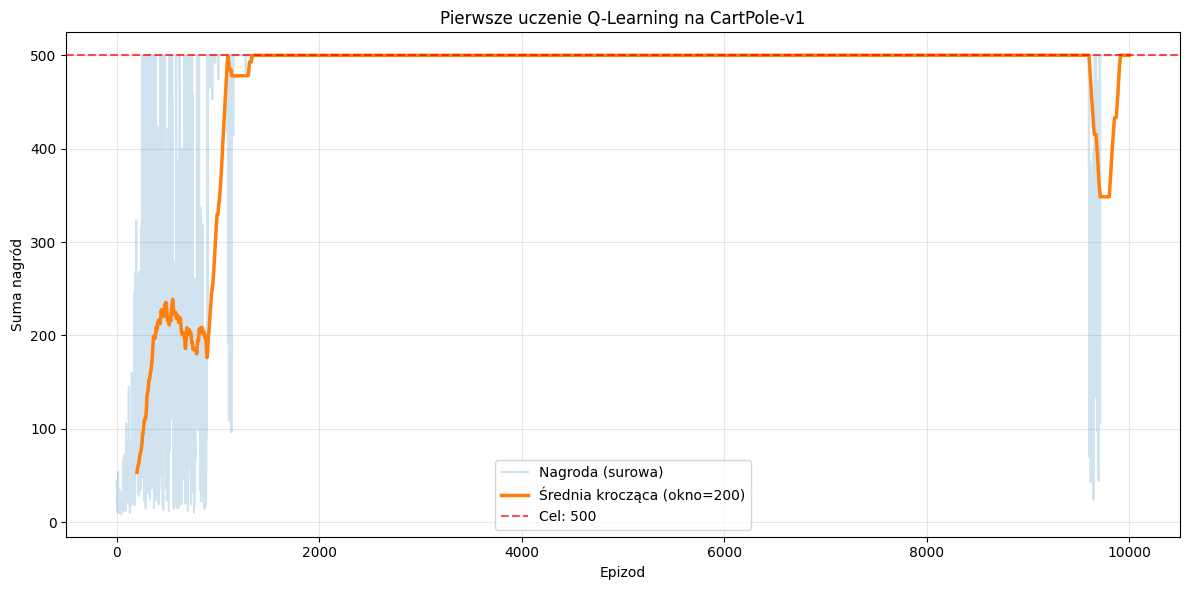

Końcowe epsilon: 0.0010
Średnia z ostatnich 200 epizodów: 500.00


array([ 44.,  19.,  20., ..., 500., 500., 500.], shape=(10000,))

In [19]:
main()

## Zadanie 2 Analiza statystyczna wyników

Jeżeli wszystko się udało w poprzedniej części przed chwilą zobaczyłeś serie liczb prawdopodobnie niezbiegających w żadnym sensownym kierunku, aby wyniki zmierzały do 500 należy dobrać prawidłowe parametry alfa, gamma i epsilon. Dobieranie parametrów na oko jest możliwe, choć bardzo kłopotliwe. Z tego powodu stwórz wykresy nagrody w kolejnych krokach czasowych. Jeżeli to zrobisz, zobaczysz, że taki wykres jest mało pomocny ze względu na niestabilność poszczególnych wyników.
- Średnia krocząca - wygładź wykresy z użyciem średniej kroczącej, dobierz odpowiednie okno 10 to dobry punkt startu.
- Odchylanie standartowe - wyniki z jednej próby są nieistotne statystycznie. Powtórz proces uczenia kilka razy i oznacz na wykresie średnia i średnią ± odchylenie standardowe z przynajmniej 5 prób

Liczba kombinacji do sprawdzenia: 24
[1/24] last100=295.58, best=419.99, params={'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.995, 'epsilon_min': 0.01, 'buckets': (1, 1, 6, 12), 'failure_penalty': -10.0}
[2/24] last100=493.70, best=500.00, params={'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.995, 'epsilon_min': 0.01, 'buckets': (1, 1, 8, 12), 'failure_penalty': -10.0}
[3/24] last100=496.05, best=500.00, params={'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.997, 'epsilon_min': 0.01, 'buckets': (1, 1, 6, 12), 'failure_penalty': -10.0}
[4/24] last100=274.37, best=457.52, params={'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.997, 'epsilon_min': 0.01, 'buckets': (1, 1, 8, 12), 'failure_penalty': -10.0}
[5/24] last100=496.84, best=498.80, params={'alpha': 0.05, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_decay': 0.995, 'epsilon_min': 0.01, 'buckets': (1, 1, 6, 12), 'failure_penalty': -10.0}
[6/24] last100=409.32, best=

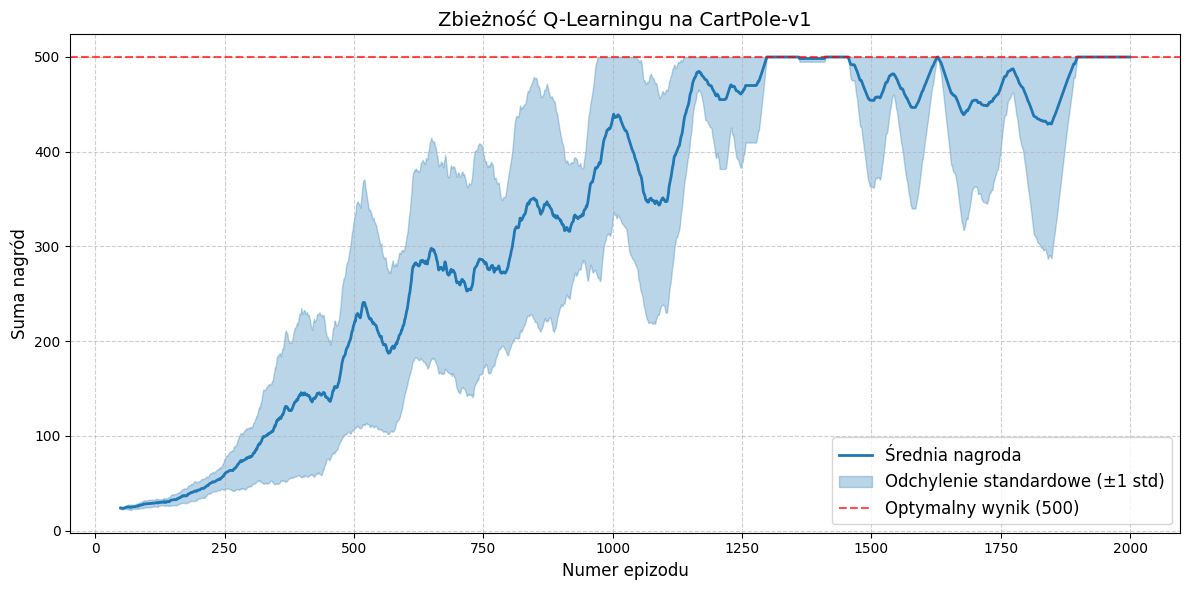

In [21]:
# Zadanie 2: analiza statystyczna + grid search (wersja stabilniejsza)
def moving_average(data, window_size):
    data = np.asarray(data, dtype=float)
    if window_size <= 1 or len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')


def evaluate_params(params, episodes=2000, repeats=5, window_size=50, verbose=False):
    all_rewards = []

    for run in range(repeats):
        learner = QLearner(
            alpha=params['alpha'],
            gamma=params['gamma'],
            epsilon=params['epsilon'],
            epsilon_decay=params['epsilon_decay'],
            epsilon_min=params['epsilon_min'],
            buckets=params['buckets'],
            failure_penalty=params['failure_penalty'],
            seed=100 + run,
        )
        rewards = learner.learn(episodes)
        learner.environment.close()
        all_rewards.append(rewards)

        if verbose:
            print(f"powtórzenie {run + 1}/{repeats}, średnia={np.mean(rewards):.2f}")

    all_rewards = np.array(all_rewards, dtype=float)
    smoothed_rewards = np.array([moving_average(run, window_size) for run in all_rewards])

    mean_rewards = np.mean(smoothed_rewards, axis=0)
    std_rewards = np.std(smoothed_rewards, axis=0)
    x = np.arange(len(mean_rewards)) + window_size - 1

    score_last_100 = np.mean(mean_rewards[-100:]) if len(mean_rewards) >= 100 else np.mean(mean_rewards)
    score_best_window = np.max(mean_rewards)

    return {
        'params': params,
        'x': x,
        'mean_rewards': mean_rewards,
        'std_rewards': std_rewards,
        'score_last_100': float(score_last_100),
        'score_best_window': float(score_best_window),
    }


def plot_summary(summary):
    x = summary['x']
    mean_rewards = summary['mean_rewards']
    std_rewards = summary['std_rewards']

    plt.figure(figsize=(12, 6))
    plt.plot(x, mean_rewards, label='Średnia nagroda', color='#1f77b4', linewidth=2)
    plt.fill_between(
        x,
        np.clip(mean_rewards - std_rewards, 0, 500),
        np.clip(mean_rewards + std_rewards, 0, 500),
        color='#1f77b4',
        alpha=0.3,
        label='Odchylenie standardowe (±1 std)',
    )
    plt.axhline(y=500, color='r', linestyle='--', alpha=0.7, label='Optymalny wynik (500)')

    plt.title('Zbieżność Q-Learningu na CartPole-v1', fontsize=14)
    plt.xlabel('Numer epizodu', fontsize=12)
    plt.ylabel('Suma nagród', fontsize=12)
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


def grid_search_qlearning(
    grid,
    episodes=2000,
    repeats=5,
    window_size=50,
    top_k=5,
    sort_key='score_last_100',
):
    keys = list(grid.keys())
    combinations = list(product(*(grid[key] for key in keys)))
    print(f'Liczba kombinacji do sprawdzenia: {len(combinations)}')

    results = []
    for idx, combo in enumerate(combinations, start=1):
        params = dict(zip(keys, combo))
        summary = evaluate_params(
            params,
            episodes=episodes,
            repeats=repeats,
            window_size=window_size,
            verbose=False,
        )
        results.append(summary)
        print(
            f"[{idx}/{len(combinations)}] "
            f"last100={summary['score_last_100']:.2f}, "
            f"best={summary['score_best_window']:.2f}, "
            f"params={params}"
        )

    ranked = sorted(results, key=lambda x: x[sort_key], reverse=True)
    print('\nTOP konfiguracje:')
    for i, item in enumerate(ranked[:top_k], start=1):
        print(
            f"{i}. {sort_key}={item[sort_key]:.2f}, "
            f"best={item['score_best_window']:.2f}, "
            f"params={item['params']}"
        )

    return ranked


# ---- konfiguracja grid search ----
param_grid = {
    'alpha': [0.05, 0.1, 0.2],
    'gamma': [0.98, 0.99],
    'epsilon': [1.0],
    'epsilon_decay': [0.995, 0.997],
    'epsilon_min': [0.01],
    'buckets': [(1, 1, 6, 12), (1, 1, 8, 12)],
    'failure_penalty': [-10.0],
}


# Szybki test: episodes=1200, repeats=3
ranked_results = grid_search_qlearning(
    param_grid,
    episodes=2000,
    repeats=5,
    window_size=50,
    top_k=5,
    sort_key='score_last_100',
)


best_summary = ranked_results[0]
print('\nNajlepsza konfiguracja:', best_summary['params'])
plot_summary(best_summary)

# Sarsa
Algorytm SARSA (nie mylić z piosenkarką, skrót od state–action–reward–state–action) jest wariantem
Q-Learning korzystającym z delikatnie zmodyfikowanego schematu uczenia, opisane poniższym
wzorem.

$$
Q^{new}(s_t,a_t) \gets   Q(s_t,a_t) +  α *  [r_t +  γ * Q(s_{t+1},a_{t+1}) -  Q(s_t,a_t)]
$$

Zwróć uwagę, że człon opisujący przyszłe zyski nie zawiera teraz maksimum po możliwych akcjach, $a$
rzeczywistą akcję $a_{t+1}$ podjętą w iteracji kolejnej po iteracji $t$. Ma to dwie konsekwencje.
* Algorytm uwzględnia zagrożenia związane z tym, że wykonywana akcja nie zawsze jest tą
optymalną (bo przecież jest szansa na eksperyment). Stany w których losowy wybór akcji
wiąże się z potencjalnie dużą karą (potocznie „kroczenie nad brzegiem przepaści” – jedna-
dwie nieoptymalne akcje mogą skończyć się tragedią) będą niepożądane.
* Aby zaktualizować wiedzę konieczna jest znajomość zarówno akcji $a_t$, jak i kolejnej $a_{t+1}$. W
kroku uczenia należy pamiętać je obie (a nie tylko ostatnią)

## Zadanie 3
Zmodyfikuj kod, by realizował algorytm SARSA. Porównaj jego
działanie (dla wybranej grupy parametrów) z działaniem Q-Learning, używając omówionych wcześniej technik wizualizacji.

In [3]:
class SARSALearner(QLearner):
    def attempt(self):
        if self.seed is not None and self.attempt_no == 1:
            observation_raw, _ = self.environment.reset(seed=self.seed)
        else:
            observation_raw, _ = self.environment.reset()

        observation = self.discretise(observation_raw)
        terminated, truncated = False, False
        reward_sum = 0.0

        action = self.pick_action(observation)

        while not truncated and not terminated:
            new_observation_raw, reward, terminated, truncated, _ = self.environment.step(action)
            new_observation = self.discretise(new_observation_raw)
            reward_sum += reward

            learning_reward = reward
            if terminated and reward_sum < 499:
                learning_reward = self.failure_penalty

            next_action = self.pick_action(new_observation) if not terminated else None

            self.update_knowledge(
                action=action,
                observation=observation,
                reward=learning_reward,
                new_observation=new_observation,
                next_action=next_action,
                terminated=terminated,
            )

            observation = new_observation
            action = next_action if next_action is not None else action

        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.attempt_no += 1
        return reward_sum

    def update_knowledge(self, action, observation, reward, new_observation, next_action, terminated):
        current_q = self.q_table[observation][action]
        if terminated:
            td_target = reward
        else:
            td_target = reward + self.gamma * self.q_table[new_observation][next_action]
        td_error = td_target - current_q
        self.q_table[observation][action] += self.alpha * td_error

Uruchamiam porównanie dla najlepszych parametrów z Zadania 2...
Parametry: {'alpha': 0.05, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_decay': 0.997, 'epsilon_min': 0.01, 'buckets': (1, 1, 8, 12), 'failure_penalty': -10.0}


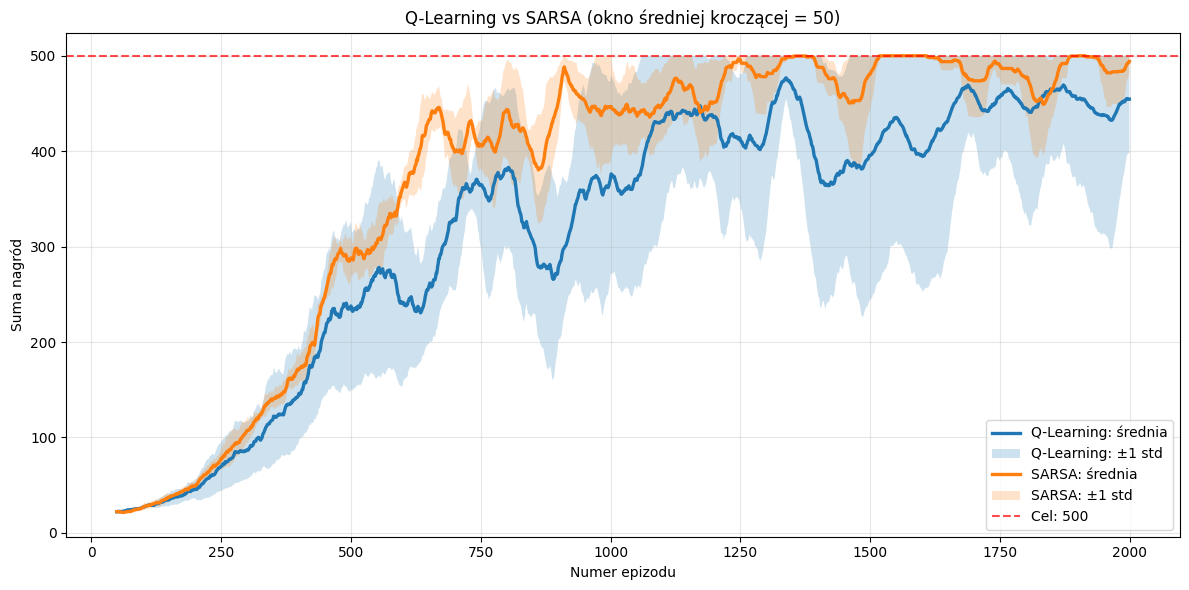

Q-Learning: średnia z ostatnich 100 punktów wygładzonej krzywej = 444.87
SARSA:      średnia z ostatnich 100 punktów wygładzonej krzywej = 491.19


In [ ]:
def run_multiple_trials(learner_cls, params, episodes=2000, repeats=5, window=50, base_seed=1000):
    all_rewards = []
    for run in range(repeats):
        learner = learner_cls(**params, seed=base_seed + run)
        rewards = learner.learn(episodes)
        learner.environment.close()
        all_rewards.append(rewards)

    all_rewards = np.array(all_rewards, dtype=float)
    smoothed = np.array([moving_average(r, window) for r in all_rewards])
    mean_curve = smoothed.mean(axis=0)
    std_curve = smoothed.std(axis=0)
    x = np.arange(len(mean_curve)) + window - 1

    return {
        'all_rewards': all_rewards,
        'mean_curve': mean_curve,
        'std_curve': std_curve,
        'x': x,
        'last100_mean': float(mean_curve[-100:].mean()) if len(mean_curve) >= 100 else float(mean_curve.mean()),
    }


def plot_q_vs_sarsa(q_stats, sarsa_stats, window):
    plt.figure(figsize=(12, 6))

    plt.plot(q_stats['x'], q_stats['mean_curve'], linewidth=2.4, label='Q-Learning: średnia')
    plt.fill_between(
        q_stats['x'],
        np.clip(q_stats['mean_curve'] - q_stats['std_curve'], 0, 500),
        np.clip(q_stats['mean_curve'] + q_stats['std_curve'], 0, 500),
        alpha=0.22,
        label='Q-Learning: ±1 std',
    )

    plt.plot(sarsa_stats['x'], sarsa_stats['mean_curve'], linewidth=2.4, label='SARSA: średnia')
    plt.fill_between(
        sarsa_stats['x'],
        np.clip(sarsa_stats['mean_curve'] - sarsa_stats['std_curve'], 0, 500),
        np.clip(sarsa_stats['mean_curve'] + sarsa_stats['std_curve'], 0, 500),
        alpha=0.22,
        label='SARSA: ±1 std',
    )

    plt.axhline(y=500, color='r', linestyle='--', alpha=0.7, label='Cel: 500')
    plt.title(f'Q-Learning vs SARSA (okno średniej kroczącej = {window})')
    plt.xlabel('Numer epizodu')
    plt.ylabel('Suma nagród')
    plt.grid(alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


best_params = {
    'alpha': 0.05,
    'gamma': 0.99,
    'epsilon': 1.0,
    'epsilon_decay': 0.997,
    'epsilon_min': 0.01,
    'buckets': (1, 1, 8, 12),
    'failure_penalty': -10.0,
}


episodes = 2000
repeats = 5
window = 50

print('Uruchamiam porównanie dla najlepszych parametrów z Zadania 2...')
print('Parametry:', best_params)

q_stats = run_multiple_trials(
    QLearner,
    best_params,
    episodes=episodes,
    repeats=repeats,
    window=window,
    base_seed=1000,
)

sarsa_stats = run_multiple_trials(
    SARSALearner,
    best_params,
    episodes=episodes,
    repeats=repeats,
    window=window,
    base_seed=2000,
)

plot_q_vs_sarsa(q_stats, sarsa_stats, window)

print(f"Q-Learning: średnia z ostatnich 100 punktów wygładzonej krzywej = {q_stats['last100_mean']:.2f}")
print(f"SARSA:      średnia z ostatnich 100 punktów wygładzonej krzywej = {sarsa_stats['last100_mean']:.2f}")

## Zadanie domowe 4
Zadania do wykonania na zajęciach zostały rozpisane trochę „na wyrost” – po to by najaktywniejsi (i
będący danego dnia w dobrej kondycji umysłowej) mieli co robić w trakcie trwania laboratorium.
Pierwszą kwestią do zrobienia w domu jest więc po prostu dokończenie tego, czego nie udało się
zrealizować „na żywo” i wykonanie z tego raportu.

Podsumuj pracę nad zadaniami 1-3 i jej rezultaty w formie raportu
w pliku PDF. Pamiętaj o tym, by umieścić go jako rozwiązanie na UPEL. Jest on
nawet ważniejszy niż kod!

## Lądowanie na księżycu
Ostatnim krokiem jest wykorzystanie poznanego algorytmu do próby rozwiązania trudniejszego
problemu – sterowania lądownikiem księżycowym. W bibliotece Gym jest on nazwany „LunarLander-v2".
Zaadaptuj istniejący kod do
walki z tym zadaniem i wyląduj (umiarkowanie) bezpiecznie na księżycu!
* Możliwe akcje to: uruchom lewą dyszę sterującą, uruchom prawą dyszę, uruchom dolną
dyszę, nie rób niczego.
* Dobierz przedział rozważanych wartości i ziarnistość dyskretyzacji do nowych obserwacji
środowiska.
o W tym celu warto wykonać szybki histogram wartości otrzymywanych w trakcie
losowego lotu.
o Przydaje się też przejrzenie kodu źródłowego problemu.
* Uczenie musi przebiegać znacząco wolniej i dłużej – to nie jest łatwy problem dla tak
uproszczonego algorytmu.
* Powinno się jednak udać uzyskać dodatnie nagrody (rzędu 50 jednostek) – a jeżeli nie, to
przynajmniej mniejsze kary niż przy losowym zachowaniu.
* Skuteczna procedura ucząca z wykorzystaniem komputera osobistego może być
czasochłonna (kilka h).

## Zadanie na 5
Jak tym razem spisał się algorytm? Uzupełnij raport o wykresy i
wnioski z pracy nad lądownikiem księżycowym.

Szacowanie granic dyskretyzacji na podstawie losowych lotów...
Aktywne środowisko: LunarLander-v3
Dolne granice: [-0.945 -0.196 -1.699 -1.742 -1.447 -0.611  0.     0.   ]
Górne granice: [0.902 1.755 1.551 0.506 1.743 0.758 1.    1.   ]

=== FAZA A: Coarse Search (SARSA) ===
Liczba konfiguracji do sprawdzenia: 144
[1/144] tail=-126.56, peak=-121.95, params={'env_name': 'LunarLander-v3', 'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.9995, 'epsilon_min': 0.02, 'buckets': (3, 3, 3, 3, 4, 4, 2, 2), 'failure_penalty': -100.0}
[2/144] tail=-134.30, peak=-125.97, params={'env_name': 'LunarLander-v3', 'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.9995, 'epsilon_min': 0.02, 'buckets': (3, 3, 3, 3, 4, 4, 2, 2), 'failure_penalty': -130.0}
[3/144] tail=-98.89, peak=-89.40, params={'env_name': 'LunarLander-v3', 'alpha': 0.05, 'gamma': 0.98, 'epsilon': 1.0, 'epsilon_decay': 0.9995, 'epsilon_min': 0.02, 'buckets': (4, 4, 4, 4, 6, 6, 2, 2), 'failure_penalty': -100.

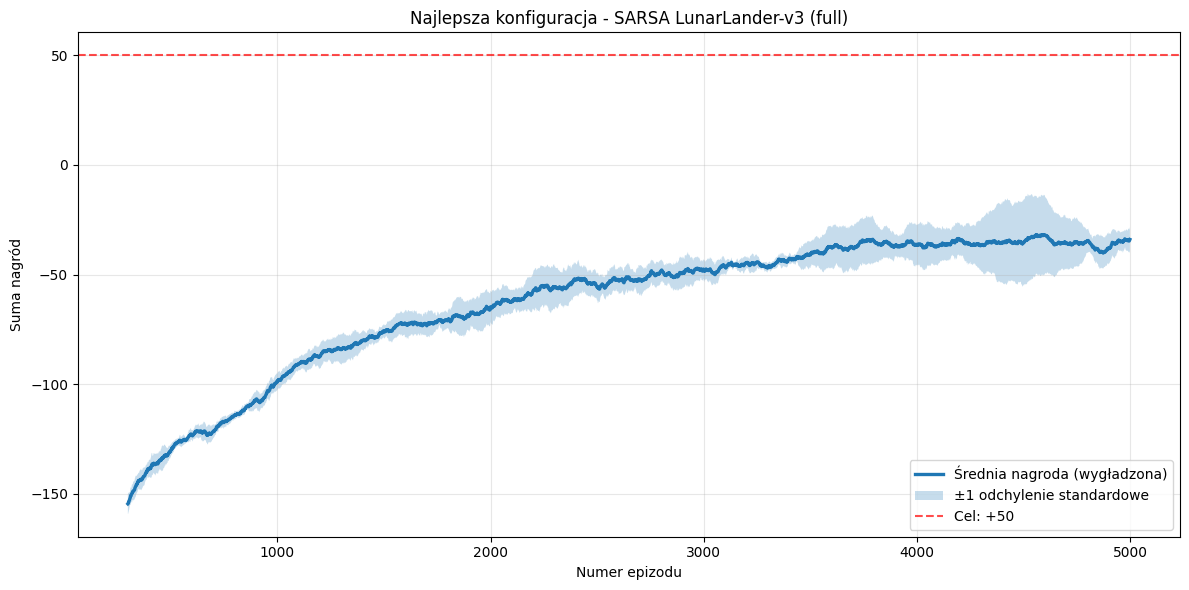


Wyniki końcowe:
score_tail (średnia z końca): -36.71
score_peak (maks. średniej krzywej): -31.83
Najlepsze parametry: {'env_name': 'LunarLander-v3', 'alpha': 0.12, 'gamma': 0.992, 'epsilon': 1.0, 'epsilon_decay': 0.9993, 'epsilon_min': 0.02, 'buckets': (4, 4, 4, 4, 6, 6, 2, 2), 'failure_penalty': -100.0}


In [6]:
# Zadanie: LunarLander tylko SARSA + wyszukiwanie najlepszych parametrów
# Uwaga: domyślnie RUN_MODE='debug' dla szybkiego sanity-checku.
# Do pełnego, długiego strojenia ustaw RUN_MODE='full'.

from collections import defaultdict
from itertools import product
import math
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt


def moving_average(data, window_size):
    data = np.asarray(data, dtype=float)
    if window_size <= 1 or len(data) < window_size:
        return data
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')


def resolve_lunar_env_id(preferred='LunarLander-v3'):
    candidates = [preferred]
    if preferred != 'LunarLander-v3':
        candidates.append('LunarLander-v3')

    last_error = None
    for candidate in candidates:
        try:
            env = gym.make(candidate)
            env.close()
            return candidate
        except Exception as ex:
            last_error = ex

    raise RuntimeError(
        "Nie udało się uruchomić LunarLandera (v2 ani v3). "
        "Doinstaluj zależności Box2D, np.: pip install gymnasium[box2d]"
    ) from last_error


def collect_random_observations(env_id='LunarLander-v3', episodes=120, seed=123):
    observations = []
    active_env_id = resolve_lunar_env_id(env_id)
    env = gym.make(active_env_id)

    try:
        for ep in range(episodes):
            obs, _ = env.reset(seed=seed + ep)
            done = False
            while not done:
                observations.append(obs)
                action = env.action_space.sample()
                obs, _, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
    finally:
        env.close()

    observations = np.asarray(observations, dtype=float)
    if observations.ndim != 2 or observations.shape[1] != 8:
        raise RuntimeError(f"Nieoczekiwany kształt obserwacji: {observations.shape}. Oczekiwano (*, 8).")

    return observations, active_env_id


def estimate_bounds_from_random_rollouts(env_id='LunarLander-v3', episodes=120, seed=123):
    obs, active_env_id = collect_random_observations(env_id=env_id, episodes=episodes, seed=seed)

    # Dla pierwszych 6 cech: kwantyle + margines, by uniknąć zbyt ciasnych granic.
    lower = np.quantile(obs[:, :6], 0.01, axis=0)
    upper = np.quantile(obs[:, :6], 0.99, axis=0)

    width = upper - lower
    lower -= 0.10 * width
    upper += 0.10 * width

    # Minimalna szerokość przedziału na każdą z 6 cech.
    min_width = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float)
    centers = 0.5 * (lower + upper)
    half_width = np.maximum(0.5 * (upper - lower), 0.5 * min_width)
    lower = centers - half_width
    upper = centers + half_width

    # Ograniczenia sensowne fizycznie.
    lower = np.maximum(lower, np.array([-2.0, -2.0, -3.0, -3.0, -math.pi, -6.0]))
    upper = np.minimum(upper, np.array([2.0, 2.0, 3.0, 3.0, math.pi, 6.0]))

    # 2 ostatnie cechy to kontakty nóg: [0, 1]
    lower_full = list(lower) + [0.0, 0.0]
    upper_full = list(upper) + [1.0, 1.0]
    return lower_full, upper_full, active_env_id


class LunarLanderSARSALearner(SARSALearner):
    def __init__(
        self,
        env_name='LunarLander-v3',
        alpha=0.08,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.9997,
        epsilon_min=0.03,
        buckets=(4, 4, 4, 4, 6, 6, 2, 2),
        failure_penalty=-120.0,
        seed=None,
        lower_bounds=None,
        upper_bounds=None,
    ):
        resolved_env_name = resolve_lunar_env_id(env_name)
        self.environment = gym.make(resolved_env_name)
        self.env_name = resolved_env_name

        self.attempt_no = 1

        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.buckets = buckets
        self.failure_penalty = failure_penalty
        self.seed = seed

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.q_table = defaultdict(lambda: np.zeros(self.environment.action_space.n, dtype=float))

        if lower_bounds is None or upper_bounds is None:
            lower_bounds, upper_bounds, _ = estimate_bounds_from_random_rollouts(
                env_id=resolved_env_name,
                episodes=100,
                seed=seed if seed is not None else 123,
            )

        if len(lower_bounds) != 8 or len(upper_bounds) != 8:
            raise ValueError("Dla LunarLandera wymagane jest 8 granic dolnych i 8 górnych.")

        self.lower_bounds = list(lower_bounds)
        self.upper_bounds = list(upper_bounds)

    def discretise(self, observation):
        discretised = []
        for i, value in enumerate(observation):
            # Kontakty nóg są binarne (0/1) - używamy twardego mapowania.
            if i in (6, 7):
                discretised.append(int(value >= 0.5))
                continue

            low = self.lower_bounds[i]
            high = self.upper_bounds[i]
            if high <= low:
                discretised.append(0)
                continue

            clipped = min(high, max(low, value))
            scaling = (clipped - low) / (high - low)
            bucket_index = int(round((self.buckets[i] - 1) * scaling))
            bucket_index = min(self.buckets[i] - 1, max(0, bucket_index))
            discretised.append(bucket_index)

        return tuple(discretised)


def evaluate_sarsa_params(
    params,
    episodes=2000,
    repeats=3,
    window_size=200,
    base_seed=1000,
    lower_bounds=None,
    upper_bounds=None,
):
    all_rewards = []

    for run in range(repeats):
        learner = LunarLanderSARSALearner(
            env_name=params.get('env_name', 'LunarLander-v3'),
            alpha=params['alpha'],
            gamma=params['gamma'],
            epsilon=params['epsilon'],
            epsilon_decay=params['epsilon_decay'],
            epsilon_min=params['epsilon_min'],
            buckets=params['buckets'],
            failure_penalty=params['failure_penalty'],
            seed=base_seed + run,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
        )
        rewards = learner.learn(episodes)
        learner.environment.close()
        all_rewards.append(rewards)

    all_rewards = np.asarray(all_rewards, dtype=float)
    smoothed = np.asarray([moving_average(run, window_size) for run in all_rewards])

    mean_curve = np.mean(smoothed, axis=0)
    std_curve = np.std(smoothed, axis=0)
    x = np.arange(len(mean_curve)) + window_size - 1

    tail = min(200, len(mean_curve))
    score_tail = float(np.mean(mean_curve[-tail:])) if tail > 0 else float(np.mean(mean_curve))
    score_peak = float(np.max(mean_curve)) if len(mean_curve) > 0 else float('-inf')

    return {
        'params': params,
        'x': x,
        'mean_curve': mean_curve,
        'std_curve': std_curve,
        'score_tail': score_tail,
        'score_peak': score_peak,
    }


def grid_search_sarsa(
    grid,
    episodes=2000,
    repeats=3,
    window_size=200,
    sort_key='score_tail',
    top_k=5,
    base_seed=1000,
    lower_bounds=None,
    upper_bounds=None,
):
    keys = list(grid.keys())
    combinations = list(product(*(grid[k] for k in keys)))
    print(f"Liczba konfiguracji do sprawdzenia: {len(combinations)}")

    results = []
    for idx, combo in enumerate(combinations, start=1):
        params = dict(zip(keys, combo))
        summary = evaluate_sarsa_params(
            params=params,
            episodes=episodes,
            repeats=repeats,
            window_size=window_size,
            base_seed=base_seed,
            lower_bounds=lower_bounds,
            upper_bounds=upper_bounds,
        )
        results.append(summary)
        print(
            f"[{idx}/{len(combinations)}] "
            f"tail={summary['score_tail']:.2f}, peak={summary['score_peak']:.2f}, params={params}"
        )

    ranked = sorted(results, key=lambda item: item[sort_key], reverse=True)

    print("\nTOP konfiguracje:")
    for i, item in enumerate(ranked[:top_k], start=1):
        print(
            f"{i}. {sort_key}={item[sort_key]:.2f}, peak={item['score_peak']:.2f}, params={item['params']}"
        )

    return ranked


def build_refine_grid(best_params):
    alpha = best_params['alpha']
    gamma = best_params['gamma']
    decay = best_params['epsilon_decay']
    eps_min = best_params['epsilon_min']
    buckets = best_params['buckets']
    penalty = best_params['failure_penalty']
    env_name = best_params.get('env_name', 'LunarLander-v2')

    alpha_vals = sorted({max(0.03, round(alpha * 0.7, 4)), alpha, min(0.30, round(alpha * 1.3, 4))})
    gamma_vals = sorted({max(0.96, round(gamma - 0.002, 4)), gamma, min(0.999, round(gamma + 0.002, 4))})
    decay_vals = sorted({max(0.9990, round(decay - 0.0002, 6)), decay, min(0.99995, round(decay + 0.0002, 6))})
    eps_min_vals = sorted({max(0.005, round(eps_min * 0.5, 4)), eps_min})

    return {
        'env_name': [env_name],
        'alpha': alpha_vals,
        'gamma': gamma_vals,
        'epsilon': [1.0],
        'epsilon_decay': decay_vals,
        'epsilon_min': eps_min_vals,
        'buckets': [buckets],
        'failure_penalty': [penalty],
    }


def plot_best_summary(best_summary, title_suffix='SARSA LunarLander'):
    x = best_summary['x']
    mean_curve = best_summary['mean_curve']
    std_curve = best_summary['std_curve']

    plt.figure(figsize=(12, 6))
    plt.plot(x, mean_curve, linewidth=2.4, label='Średnia nagroda (wygładzona)')
    plt.fill_between(
        x,
        mean_curve - std_curve,
        mean_curve + std_curve,
        alpha=0.25,
        label='±1 odchylenie standardowe',
    )
    plt.axhline(y=50, color='r', linestyle='--', alpha=0.7, label='Cel: +50')
    plt.title(f'Najlepsza konfiguracja - {title_suffix}')
    plt.xlabel('Numer epizodu')
    plt.ylabel('Suma nagród')
    plt.grid(alpha=0.3)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


# ========================================
# Konfiguracja uruchomienia
# ========================================
RUN_MODE = 'full'  # 'debug' albo 'full'

if RUN_MODE == 'full':
    # Budżet długi: coarse + refine (1-3h+, zależnie od sprzętu)
    coarse_episodes = 1800
    coarse_repeats = 2
    coarse_window = 200

    refine_episodes = 3500
    refine_repeats = 3
    refine_window = 300

    final_episodes = 5000
    final_repeats = 5
    final_window = 300

    random_sample_episodes = 150
else:
    # Szybki sanity-check
    coarse_episodes = 300
    coarse_repeats = 2
    coarse_window = 40

    refine_episodes = 600
    refine_repeats = 2
    refine_window = 70

    final_episodes = 900
    final_repeats = 3
    final_window = 100

    random_sample_episodes = 50


print('Szacowanie granic dyskretyzacji na podstawie losowych lotów...')
lower_bounds, upper_bounds, active_env_id = estimate_bounds_from_random_rollouts(
    env_id='LunarLander-v3',
    episodes=random_sample_episodes,
    seed=321,
)

print('Aktywne środowisko:', active_env_id)
print('Dolne granice:', np.round(lower_bounds, 3))
print('Górne granice:', np.round(upper_bounds, 3))


# ----------------------------------------
# Faza A: Coarse Search
# ----------------------------------------
if RUN_MODE == 'full':
    coarse_grid = {
        'env_name': [active_env_id],
        'alpha': [0.05, 0.08, 0.12],
        'gamma': [0.98, 0.99],
        'epsilon': [1.0],
        'epsilon_decay': [0.9995, 0.9997, 0.99985],
        'epsilon_min': [0.02, 0.05],
        'buckets': [
            (3, 3, 3, 3, 4, 4, 2, 2),
            (4, 4, 4, 4, 6, 6, 2, 2),
        ],
        'failure_penalty': [-100.0, -130.0],
    }
else:
    coarse_grid = {
        'env_name': [active_env_id],
        'alpha': [0.05, 0.10],
        'gamma': [0.99],
        'epsilon': [1.0],
        'epsilon_decay': [0.9997, 0.99985],
        'epsilon_min': [0.03],
        'buckets': [
            (3, 3, 3, 3, 4, 4, 2, 2),
            (4, 4, 4, 4, 6, 6, 2, 2),
        ],
        'failure_penalty': [-120.0],
    }

print('\n=== FAZA A: Coarse Search (SARSA) ===')
coarse_ranked = grid_search_sarsa(
    grid=coarse_grid,
    episodes=coarse_episodes,
    repeats=coarse_repeats,
    window_size=coarse_window,
    sort_key='score_tail',
    top_k=5,
    base_seed=1000,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

best_coarse = coarse_ranked[0]
print('\nNajlepsza konfiguracja po Fazie A:', best_coarse['params'])


# ----------------------------------------
# Faza B: Refinement wokół best z A
# ----------------------------------------
refine_grid = build_refine_grid(best_coarse['params'])
print('\n=== FAZA B: Refinement (SARSA) ===')
refine_ranked = grid_search_sarsa(
    grid=refine_grid,
    episodes=refine_episodes,
    repeats=refine_repeats,
    window_size=refine_window,
    sort_key='score_tail',
    top_k=5,
    base_seed=5000,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

best_params = refine_ranked[0]['params']
print('\nNajlepsza konfiguracja końcowa (SARSA):', best_params)


# ----------------------------------------
# Finalna ewaluacja + wykresy best params
# ----------------------------------------
print('\n=== Finalna ewaluacja najlepszych parametrów ===')
best_summary = evaluate_sarsa_params(
    params=best_params,
    episodes=final_episodes,
    repeats=final_repeats,
    window_size=final_window,
    base_seed=9000,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

plot_best_summary(best_summary, title_suffix=f"SARSA {active_env_id} ({RUN_MODE})")

print('\nWyniki końcowe:')
print(f"score_tail (średnia z końca): {best_summary['score_tail']:.2f}")
print(f"score_peak (maks. średniej krzywej): {best_summary['score_peak']:.2f}")
print('Najlepsze parametry:', best_params)